# Proyecto 1: Regresión Lineal Simple
### Dataset: Salary Dataset — Predicción de Salario por Años de Experiencia
---
## Objetivo
Construir un modelo de **Regresión Lineal Simple** que prediga el salario de un empleado a partir de sus años de experiencia.

Al completar este notebook serás capaz de:
- Preprocesar datos para Machine Learning.
- Entrenar y evaluar un modelo de regresión lineal simple.
- Interpretar los coeficientes β₀ y β₁.
- Analizar residuos y métricas de evaluación.

## ¿Qué es la Regresión Lineal Simple?
Modela la relación entre **una variable de entrada (X)** y **una salida (y)** con una línea recta:

```
ŷ = β₀ + β₁ · X
```
- `β₀` → Intercepto (valor de y cuando X = 0)  
- `β₁` → Pendiente (cuánto aumenta y por cada unidad de X)  
- `X`  → Años de experiencia  
- `ŷ`  → Salario estimado

> **Intuición:** Es la línea que "mejor se ajusta" a la nube de puntos del scatter plot.

## Paso 0 — Importar Librerías
Ejecuta la siguiente celda para importar todo lo necesario.

In [ ]:
# Importa: pandas, numpy, matplotlib.pyplot, seaborn
# Desde sklearn.model_selection importa train_test_split
# Desde sklearn.linear_model importa LinearRegression
# Desde sklearn.metrics importa mean_absolute_error, mean_squared_error, r2_score
# Configura el estilo de matplotlib con: plt.style.use('seaborn-v0_8-whitegrid')
# Imprime un mensaje de confirmación

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [23]:
import os

print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'untitled', 'Salary_dataset.csv', 'sample_data']


## Paso 1 — Cargar y Explorar los Datos
Descarga el dataset desde Kaggle: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression  
El archivo se llama `Salary_dataset.csv`.

In [24]:
# Carga el CSV con pd.read_csv() y muestra las primeras 5 filas con .head()

df = pd.read_csv('Salary_dataset.csv')
df.head(10)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imprime: número de filas, número de columnas con df.shape

df.shape

(30, 3)

In [31]:
#  tipos de datos (df.info()

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [32]:
# valores nulos (df.isnull().sum())

df.isnull().sum()

,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [33]:
# Muestra las estadísticas descriptivas con .describe().round(2)

df.describe().round(2)

,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


## Paso 2 — Análisis Exploratorio (EDA)
Antes de entrenar el modelo debemos entender visualmente los datos.

In [34]:
# Verificamos que no haya valores nulos

df.isnull().sum()


,0
Unnamed: 0,0
YearsExperience,0
Salary,0


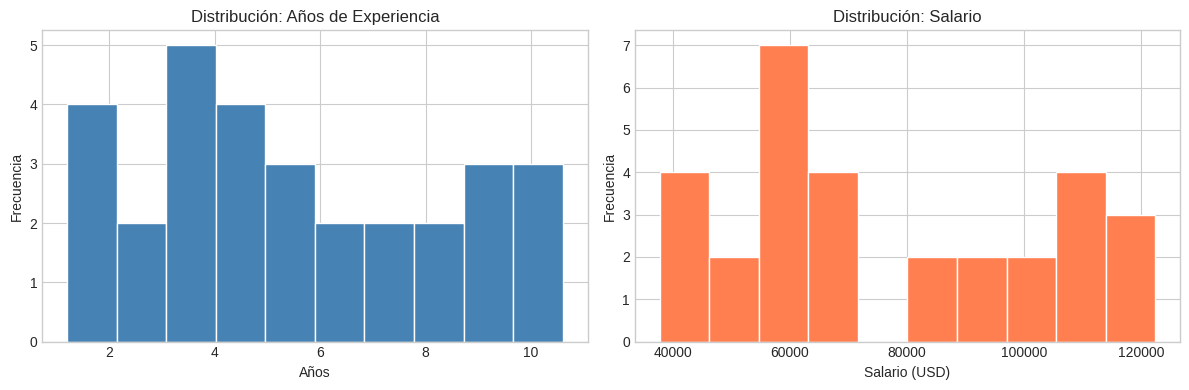

In [35]:
# Crea un subplot con 2 histogramas: uno para YearsExperience y otro para Salary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['YearsExperience'], bins=10, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución: Años de Experiencia')
axes[0].set_xlabel('Años')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['Salary'], bins=10, color='coral', edgecolor='white')
axes[1].set_title('Distribución: Salario')
axes[1].set_xlabel('Salario (USD)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


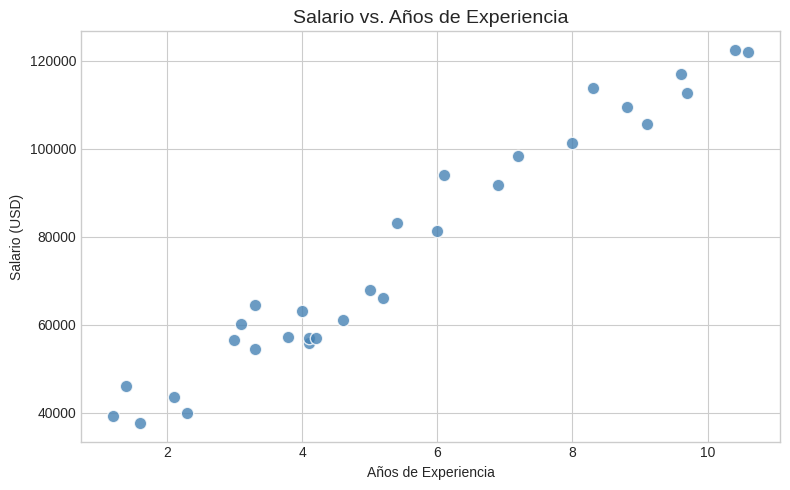

In [36]:
# Crea un scatter plot de YearsExperience (eje X) vs Salary (eje Y). Añade título, etiquetas de ejes y estilo.

plt.figure(figsize=(8, 5))
plt.scatter(df['YearsExperience'], df['Salary'], color='steelblue', s=80, alpha=0.8, edgecolors='white')
plt.title('Salario vs. Años de Experiencia', fontsize=14)
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (USD)')
plt.tight_layout()
plt.show()

In [37]:
# Calcula la correlación de Pearson entre YearsExperience y Salary con .corr()
correlacion = df['YearsExperience'].corr(df['Salary'])
print(f" Correlación de Pearson (X, y): {correlacion:.4f}")

# Imprime el resultado e interpreta: correlación > 0.95 es excelente para regresión lineal

 Correlación de Pearson (X, y): 0.9782


## Paso 3 — Preparación de los Datos
Separamos las variables y dividimos en entrenamiento (80%) y prueba (20%).

In [38]:
# Crea X = df[['YearsExperience']]  (doble corchete para que sea 2D)
# Crea y = df['Salary']
# Imprime las formas (shape) de X e y

X = df[['YearsExperience']]   # DataFrame 2D — sklearn lo requiere así
y = df['Salary']               # Series 1D

print(f" Forma de X: {X.shape}")
print(f" Forma de y: {y.shape}")

 Forma de X: (30, 1)
 Forma de y: (30,)


In [39]:
# Usa train_test_split con test_size=0.2 y random_state=42
# Imprime cuántas muestras hay en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Muestras entrenamiento: {len(X_train)}")
print(f"Muestras prueba: {len(X_test)}")

Muestras entrenamiento: 24
Muestras prueba: 6


## Paso 4 — Entrenar el Modelo
El método `.fit()` calcula los coeficientes óptimos β₀ y β₁.

In [40]:
# Crear e instanciar el modelo
# Crea una instancia de LinearRegression()
# Llama a .fit(X_train, y_train)
# Imprime modelo.intercept_ (β₀) y modelo.coef_[0] (β₁) con formato claro

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print(" Modelo entrenado exitosamente")
print("─" * 40)
print(f" Intercepto  (β₀): {modelo.intercept_:,.2f}")
print(f" Pendiente   (β₁): {modelo.coef_[0]:,.2f}")



 Modelo entrenado exitosamente
────────────────────────────────────────
 Intercepto  (β₀): 24,380.20
 Pendiente   (β₁): 9,423.82


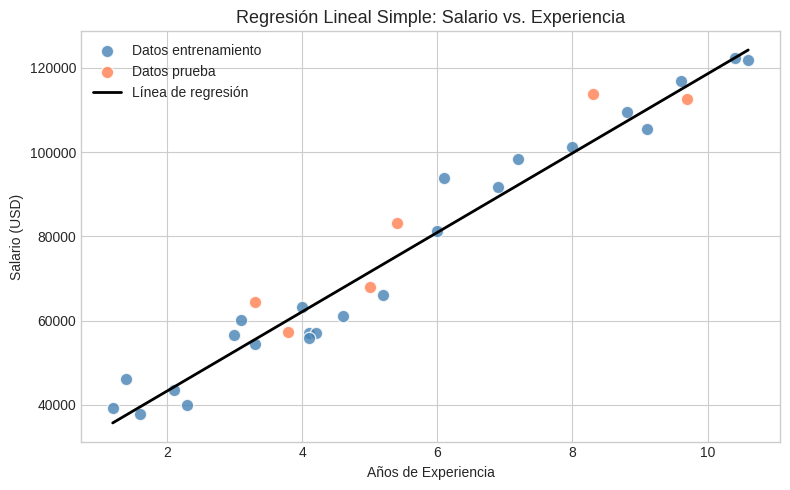

In [41]:
# Traza el scatter plot de los datos de entrenamiento (azul) y prueba (coral)
# Superpone la línea de regresión generando X_linea con np.linspace
# Usa modelo.predict(X_linea) para obtener los valores de la línea

plt.figure(figsize=(8, 5))

# Datos de prueba

plt.scatter(
    X_train,
    y_train,
    color='steelblue',
    s=80,
    alpha=0.8,
    edgecolors='white',
    label='Datos entrenamiento'
)

# Datos de prueba
plt.scatter(
    X_test,
    y_test,
    color='coral',
    s=80,
    alpha=0.8,
    edgecolors='white',
    label='Datos prueba'
)

# Línea de regresión
X_linea = pd.DataFrame(
    np.linspace(
        X['YearsExperience'].min(),
        X['YearsExperience'].max(),
        100
    ),
    columns=['YearsExperience']
)

plt.plot(
    X_linea,
    modelo.predict(X_linea),
    color='black',
    linewidth=2,
    label='Línea de regresión'
)

plt.title('Regresión Lineal Simple: Salario vs. Experiencia', fontsize=13)
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Paso 5 — Evaluación del Modelo
Calculamos las métricas sobre los datos de **prueba** (datos que el modelo no vio durante el entrenamiento).

| Métrica | Fórmula | Valor ideal |
|---|---|---|
| **MAE** | mean(\|y − ŷ\|) | Lo más bajo posible |
| **MSE** | mean((y − ŷ)²) | Lo más bajo posible |
| **RMSE** | √MSE | Lo más bajo posible |
| **R²** | 1 − SS_res/SS_tot | Cercano a 1.0 |

> **Valores esperados para este dataset:** R² ≥ 0.90, MAE < $5,000

In [42]:
# Genera predicciones: y_pred = modelo.predict(X_test)
y_pred = modelo.predict(X_test)

In [43]:
# Crea un DataFrame comparando: Años_Exp, Salario_Real, Salario_Predicho, Error
# Imprime la tabla

comparacion = pd.DataFrame({
    'Años_Exp': X_test['YearsExperience'].values,
    'Salario_Real': y_test.values,
    'Salario_Predicho': y_pred.round(2),
    'Error': (y_test.values - y_pred).round(2)
})
print("📋 Comparación Real vs Predicho:")
print(comparacion.to_string(index=False))

📋 Comparación Real vs Predicho:
 Años_Exp  Salario_Real  Salario_Predicho    Error
      9.7      112636.0         115791.21 -3155.21
      5.0       67939.0          71499.28 -3560.28
      8.3      113813.0         102597.87 11215.13
      5.4       83089.0          75268.80  7820.20
      3.3       64446.0          55478.79  8967.21
      3.8       57190.0          60190.70 -3000.70


In [44]:
# Calcula e imprime MAE, MSE, RMSE y R² usando las funciones de sklearn.metrics
# Muestra los resultados de forma clara con etiquetas

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print("=" * 45)
(" MÉTRICAS DE EVALUACIÓN")
print("=" * 45)
print(f"  MAE  (Error Absoluto Medio):    ${mae:>12,.2f}")
print(f"  MSE  (Error Cuadrático Medio):  ${mse:>12,.2f}")
print(f"  RMSE (Raíz Error Cuadrático):   ${rmse:>12,.2f}")
print(f"  R²   (Coeficiente Determinación): {r2:>10.4f}")
print("=" * 45)


  MAE  (Error Absoluto Medio):    $    6,286.45
  MSE  (Error Cuadrático Medio):  $49,830,096.86
  RMSE (Raíz Error Cuadrático):   $    7,059.04
  R²   (Coeficiente Determinación):     0.9024


## Paso 6 — Análisis de Residuos
Los **residuos** son `e = y − ŷ`. Analizarlos nos dice si el modelo es adecuado.

> **Buen modelo:** residuos distribuidos aleatoriamente alrededor de 0, sin patrón visible.  
> **Problema:** si hay curva o patrón → relación no es lineal → usar regresión polinómica.

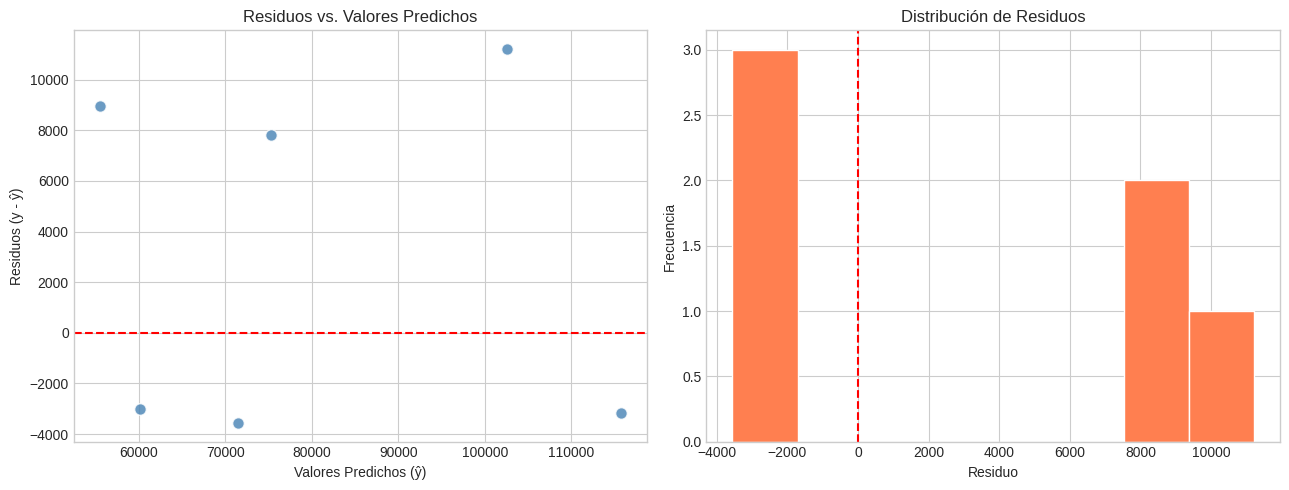

In [45]:
# Calcula residuos = y_test.values - y_pred
# Crea 2 subplots lado a lado: (6.1 y 6.2)
#   1) Scatter: residuos vs y_pred (con línea horizontal en y=0)
#   2) Histograma de residuos (con línea vertical en x=0)

residuos = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─── 6.1 Residuos vs Valores Predichos ───────────────────────────────────────
axes[0].scatter(y_pred, residuos, color='steelblue', s=70, alpha=0.8, edgecolors='white')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuos vs. Valores Predichos')
axes[0].set_xlabel('Valores Predichos (ŷ)')
axes[0].set_ylabel('Residuos (y - ŷ)')

# ─── 6.2 Distribución de residuos ────────────────────────────────────────────
axes[1].hist(residuos, bins=8, color='coral', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribución de Residuos')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## Paso 7 — ¿Qué hacer si el modelo no predice bien?
Si R² < 0.80, aplica estas estrategias de diagnóstico y ajuste.

In [46]:
# Detecta outliers: calcula umbral = 2 * residuos.std()
# Encuentra índices donde np.abs(residuos) > umbral
# Imprime las predicciones con error grande

comparacion = pd.DataFrame({
    "Valor real": y_test.values,
    "Predicción": y_pred,
    "Residuo": residuos
})

umbral = 2 * residuos.std()
outliers_idx = np.where(np.abs(residuos) > umbral)[0]

print(f"Predicciones con error grande (>{umbral:.0f} USD):")

if len(outliers_idx) > 0:
    print(comparacion.iloc[outliers_idx])
else:
    print("No se detectaron outliers significativos")


Predicciones con error grande (>12734 USD):
No se detectaron outliers significativos


In [47]:
# Calcula R² tanto en entrenamiento como en prueba
# Imprime ambos y la diferencia
# Si diferencia > 0.10 → posible overfitting

y_pred_train = modelo.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred)

print(f"R² entrenamiento: {r2_train:.4f}")
print(f"R² prueba:        {r2_test:.4f}")
print(f"Diferencia:       {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) > 0.10:
    print("  Posible overfitting — gran diferencia entre entrenamiento y prueba")
else:
    print(" Modelo generaliza bien — diferencia pequeña entre conjuntos")

R² entrenamiento: 0.9645
R² prueba:        0.9024
Diferencia:       0.0621
 Modelo generaliza bien — diferencia pequeña entre conjuntos


In [48]:
# Usa cross_val_score de sklearn.model_selection con cv=5 y scoring='r2'
# Imprime los R² por fold, el promedio y la desviación estándar

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print(" Validación Cruzada (5-Fold):")
print(f"  R² por fold: {cv_scores.round(4)}")
print(f"  R² promedio: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

 Validación Cruzada (5-Fold):
  R² por fold: [ 0.3596 -1.2442  0.2505  0.297   0.0703]
  R² promedio: -0.0534 ± 0.6032


## Paso 8 — Hacer Predicciones Nuevas

In [49]:
# Crea un DataFrame con nuevos valores de YearsExperience: [1.5, 5.0, 8.0, 10.0, 12.0]
# Usa modelo.predict() para obtener sus salarios estimados
# Imprime cada predicción de forma legible

nuevos_datos = pd.DataFrame({'YearsExperience': [1.5, 5.0, 8.0, 10.0, 12.0]})
predicciones = modelo.predict(nuevos_datos)

print(" Predicciones de salario:")
print("-" * 40)
for exp, sal in zip(nuevos_datos['YearsExperience'], predicciones):
    print(f"  {exp:>5.1f} años de experiencia → ${sal:>10,.2f} USD")


 Predicciones de salario:
----------------------------------------
    1.5 años de experiencia → $ 38,515.92 USD
    5.0 años de experiencia → $ 71,499.28 USD
    8.0 años de experiencia → $ 99,770.72 USD
   10.0 años de experiencia → $118,618.35 USD
   12.0 años de experiencia → $137,465.99 USD


## Paso 9 — Resumen y Conclusiones
Imprime un resumen completo del modelo: ecuación, métricas y resultado de validación cruzada.

In [50]:
# Imprime:
# - La ecuación completa: Salario = β₀ + β₁ × Años
# - R², MAE, RMSE del conjunto de prueba con evaluación (✅ o ⚠️)
# - R² promedio de la validación cruzada

print("=" * 50)
print("        RESUMEN DEL MODELO")
print("=" * 50)
print(f"\n  Ecuación: Salario = {modelo.intercept_:,.2f} + {modelo.coef_[0]:,.2f} × Años")
print(f"\n  Métricas sobre conjunto de prueba:")
print(f"    • R²   = {r2:.4f}  {' Excelente' if r2 >= 0.90 else ' Mejorable'}")
print(f"    • MAE  = ${mae:,.2f}")
print(f"    • RMSE = ${rmse:,.2f}")
print(f"\n  Validación cruzada (5-Fold):")
print(f"    • R² promedio = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 50)

        RESUMEN DEL MODELO

  Ecuación: Salario = 24,380.20 + 9,423.82 × Años

  Métricas sobre conjunto de prueba:
    • R²   = 0.9024   Excelente
    • MAE  = $6,286.45
    • RMSE = $7,059.04

  Validación cruzada (5-Fold):
    • R² promedio = -0.0534 ± 0.6032


## Conceptos Aprendidos

| Concepto | Descripción |
|---|---|
| **Regresión Lineal** | Ajusta una línea recta entre X e y |
| **β₀ y β₁** | Intercepto y pendiente de la recta |
| **Train/Test Split** | División de datos para evaluación honesta |
| **R²** | Porcentaje de varianza explicada (0 a 1) |
| **MAE / RMSE** | Magnitud del error en unidades originales |
| **Análisis de residuos** | Diagnóstico de supuestos del modelo |
| **Validación cruzada** | Evaluación robusta con múltiples splits |